In [4]:
import json

with open("../Results/final_results_gemini_B.json", 'r', encoding='utf-8') as f:
    data = json.load(f)

print("🔍 [데이터 진단] 처음 5개의 평가 로그 확인:\n")
for i in range(5):
    print(f"[{i+1}번 이미지] : {data[i].get('evaluation_log', '')[:80]}...")

🔍 [데이터 진단] 처음 5개의 평가 로그 확인:

[1번 이미지] : 평가 실패: {
  "error": {
    "code": 429,
    "message": "You exceeded your current...
[2번 이미지] : 평가 실패: {
  "error": {
    "code": 429,
    "message": "You exceeded your current...
[3번 이미지] : 평가 실패: {
  "error": {
    "code": 429,
    "message": "You exceeded your current...
[4번 이미지] : 평가 실패: {
  "error": {
    "code": 429,
    "message": "You exceeded your current...
[5번 이미지] : 평가 실패: {
  "error": {
    "code": 429,
    "message": "You exceeded your current...


✅ 총 4319개의 평가 데이터를 불러왔습니다.
📊 파싱 완료! 총 4166개의 유효한 점수 데이터를 시각화합니다.


/var/folders/c1/ff1kv08j2fd06b_058sckl9w0000gn/T/ipykernel_95231/452899317.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=["Baseline (원본)", "Noisy (단일 노이즈)", "Diverse (다중 앙상블)"], y=mean_scores.values, palette="Blues_d", ax=ax1)
/var/folders/c1/ff1kv08j2fd06b_058sckl9w0000gn/T/ipykernel_95231/452899317.py:90: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="Method", y="Score", data=df_melted_scores, palette="Set2", inner="quartile", ax=ax2)
/var/folders/c1/ff1kv08j2fd06b_058sckl9w0000gn/T/ipykernel_95231/452899317.py:105: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False`

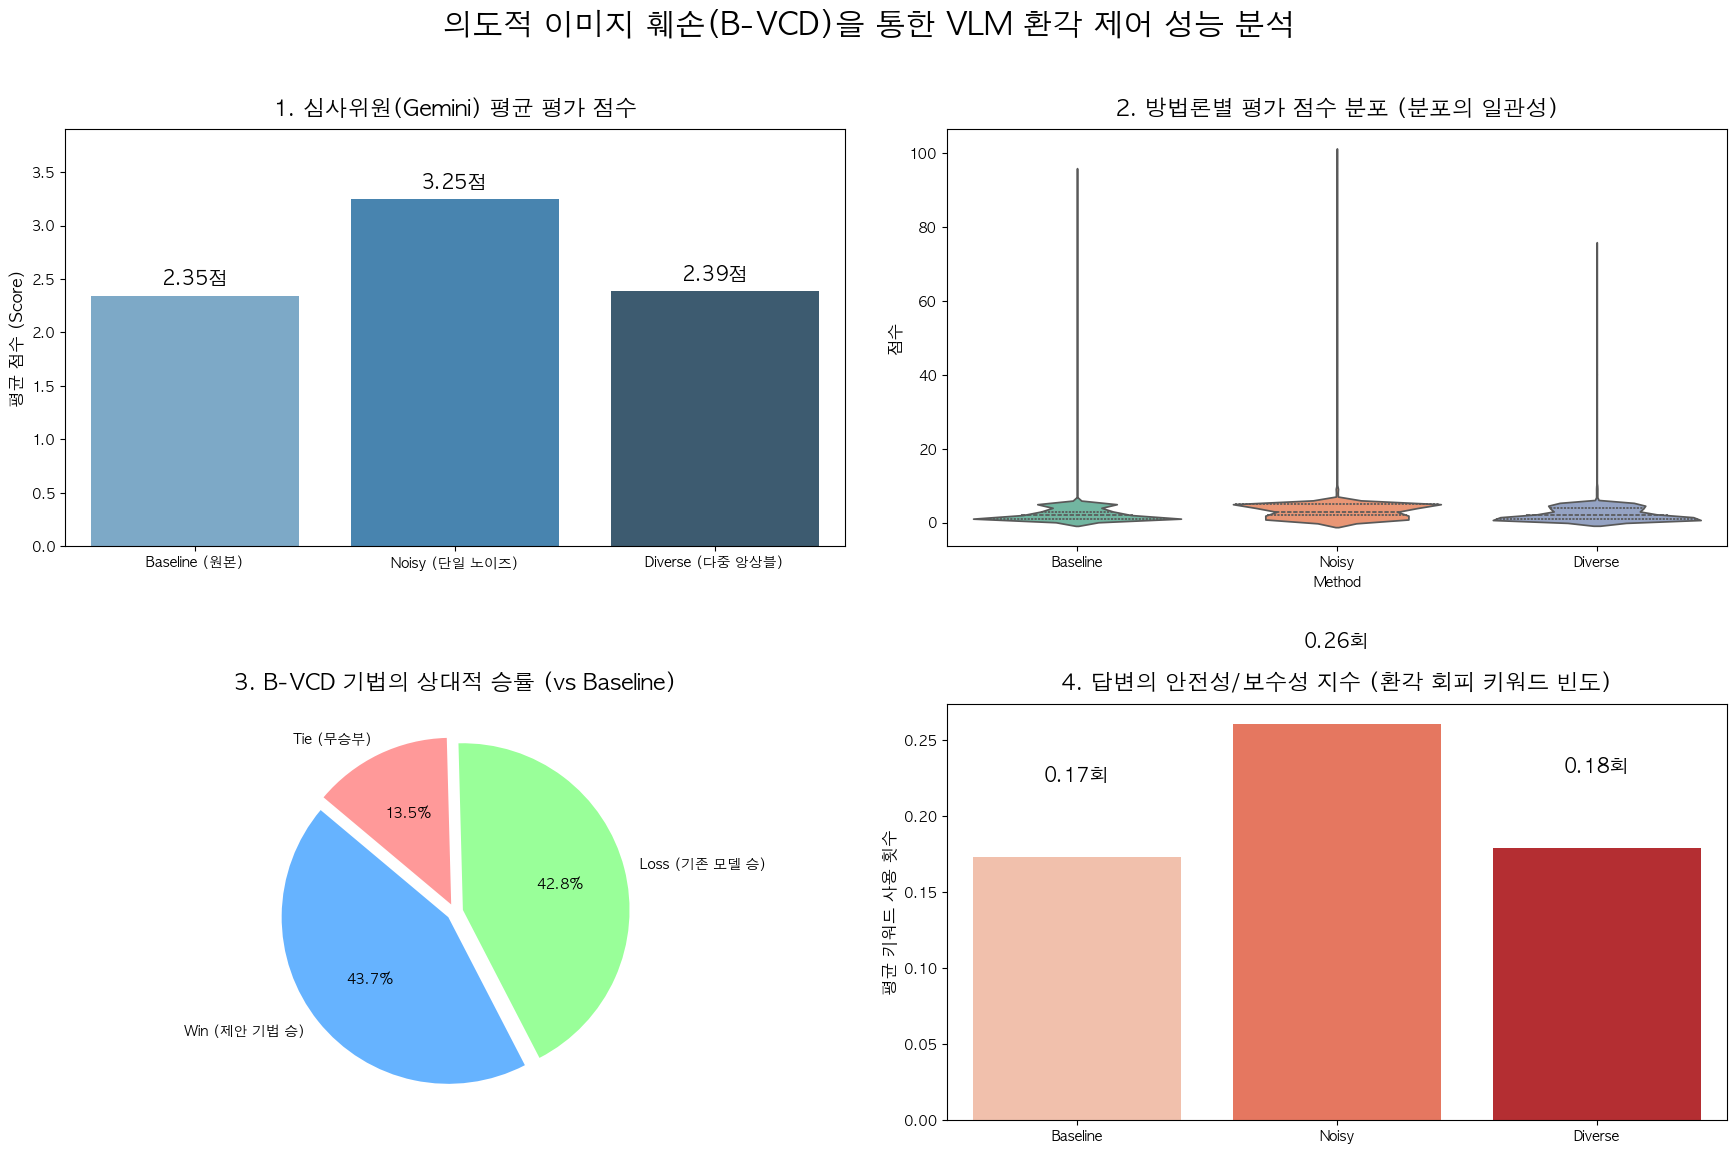

In [5]:
import os
import json
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ==========================================
# 🛠️ 환경 설정 및 데이터 로드
# ==========================================
# Mac / Windows 한글 폰트 깨짐 방지
if os.name == 'posix':
    plt.rc('font', family='AppleGothic')
else:
    plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

# 💡 최신 마스터 파일명으로 변경 완료
FILE_PATH = "../Results/final_results_gemini-2.5-flash_B-VCD.json"

try:
    with open(FILE_PATH, 'r', encoding='utf-8') as f:
        data = json.load(f)
    print(f"✅ 총 {len(data)}개의 평가 데이터를 불러왔습니다.")
except FileNotFoundError:
    print("❌ 최종 평가 파일(JSON)을 찾을 수 없습니다. 경로를 확인하세요.")
    data = []

# ==========================================
# 🔍 1. 점수 및 텍스트 데이터 정밀 추출
# ==========================================
parsed_data = []

# 보수성(안전성)을 측정하기 위한 '회피/안전 키워드' 리스트
safety_keywords = ["cannot", "not able to", "unclear", "hard to tell", "blurry", "difficult to read", "sorry", "without more information"]

for item in data:
    eval_log = item.get("evaluation_log", "")
    candidates = item.get("candidates", {})
    
    # 🌟 마크다운 볼드체(**) 등 특수기호 제거로 파싱 오류 원천 차단
    eval_log_clean = eval_log.replace('*', '')
    
    scores = {}
    safety_counts = {}
    
    for i in range(1, 4):
        # Candidate 1: 5 혹은 Candidate 1: 5/5 패턴 완벽 대응
        match = re.search(rf"Candidate\s*{i}\s*:\s*([0-9]+)(?:/[0-9]+)?", eval_log_clean, re.IGNORECASE)
        scores[f"Candidate {i}"] = int(match.group(1)) if match else None
        
        cand_text = candidates.get(f"candidate_{i}_regular" if i==1 else f"candidate_{i}_noisy" if i==2 else f"candidate_{i}_diverse", "").lower()
        safety_counts[f"Candidate {i}"] = sum(1 for kw in safety_keywords if kw in cand_text)

    parsed_data.append({
        "image": item["image"],
        "Baseline Score": scores.get("Candidate 1"),
        "Noisy Score": scores.get("Candidate 2"),
        "Diverse Score": scores.get("Candidate 3"),
        "Baseline Safety": safety_counts.get("Candidate 1"),
        "Noisy Safety": safety_counts.get("Candidate 2"),
        "Diverse Safety": safety_counts.get("Candidate 3")
    })

df = pd.DataFrame(parsed_data).dropna()
print(f"📊 파싱 완료! 총 {len(df)}개의 유효한 점수 데이터를 시각화합니다.")

# ==========================================
# 📊 2. 논문용 다각도 시각화 (4 Panel Graph)
# ==========================================
if not df.empty:
    fig = plt.figure(figsize=(18, 12))
    fig.suptitle("의도적 이미지 훼손(B-VCD)을 통한 VLM 환각 제어 성능 분석", fontsize=22, fontweight='bold', y=0.98)

    # [그래프 1] 평균 평가 점수
    ax1 = plt.subplot(2, 2, 1)
    mean_scores = df[["Baseline Score", "Noisy Score", "Diverse Score"]].mean()
    sns.barplot(x=["Baseline (원본)", "Noisy (단일 노이즈)", "Diverse (다중 앙상블)"], y=mean_scores.values, palette="Blues_d", ax=ax1)
    ax1.set_title("1. 심사위원(Gemini) 평균 평가 점수", fontsize=16, pad=10)
    ax1.set_ylabel("평균 점수 (Score)", fontsize=12)
    ax1.set_ylim(0, max(mean_scores.values) * 1.2)
    for i, v in enumerate(mean_scores.values):
        ax1.text(i, v + 0.1, f"{v:.2f}점", ha='center', fontsize=14, fontweight='bold')

    # [그래프 2] 점수 분포의 안정성
    ax2 = plt.subplot(2, 2, 2)
    df_melted_scores = df.melt(value_vars=["Baseline Score", "Noisy Score", "Diverse Score"], var_name="Method", value_name="Score")
    df_melted_scores['Method'] = df_melted_scores['Method'].str.replace(' Score', '')
    sns.violinplot(x="Method", y="Score", data=df_melted_scores, palette="Set2", inner="quartile", ax=ax2)
    ax2.set_title("2. 방법론별 평가 점수 분포 (분포의 일관성)", fontsize=16, pad=10)
    ax2.set_ylabel("점수", fontsize=12)

    # [그래프 3] 상대적 승률
    ax3 = plt.subplot(2, 2, 3)
    df['Win_vs_Baseline'] = np.where(df['Diverse Score'] > df['Baseline Score'], 'Win (제안 기법 승)',
                            np.where(df['Diverse Score'] == df['Baseline Score'], 'Tie (무승부)', 'Loss (기존 모델 승)'))
    win_counts = df['Win_vs_Baseline'].value_counts()
    ax3.pie(win_counts, labels=win_counts.index, autopct='%1.1f%%', startangle=140, colors=["#66b3ff", "#99ff99", "#ff9999"], explode=[0.05]*len(win_counts))
    ax3.set_title("3. B-VCD 기법의 상대적 승률 (vs Baseline)", fontsize=16, pad=10)

    # [그래프 4] 보수성/안전성 지표
    ax4 = plt.subplot(2, 2, 4)
    safety_means = df[["Baseline Safety", "Noisy Safety", "Diverse Safety"]].mean()
    sns.barplot(x=["Baseline", "Noisy", "Diverse"], y=safety_means.values, palette="Reds", ax=ax4)
    ax4.set_title("4. 답변의 안전성/보수성 지수 (환각 회피 키워드 빈도)", fontsize=16, pad=10)
    ax4.set_ylabel("평균 키워드 사용 횟수", fontsize=12)
    for i, v in enumerate(safety_means.values):
        ax4.text(i, v + 0.05, f"{v:.2f}회", ha='center', fontsize=14, fontweight='bold')

    plt.tight_layout(pad=3.0)
    plt.savefig("../Results/Final_Evaluation_Graphs_B-VCD.png", dpi=300) 
    plt.show()

else:
    print("❌ 유효한 점수를 추출하지 못했습니다.")